In [1]:
import re
import math
import json
import random
from pathlib import Path
from collections import defaultdict, Counter

In [2]:
import numpy as np
import pandas as pd

In [3]:
import sacrebleu
from sacrebleu.metrics import BLEU, CHRF

In [4]:
from bert_score import score as bertscore_score

In [5]:
FILE_PATHS = [
    "predictions_real1.xlsx",
    "predictions_real3.xlsx",
    "predictions_real4.xlsx",
    "predictions_real5.xlsx",
    "predictions_real6.xlsx",
]

In [6]:
LANG = "zh" # "auto" 
# BERT_MODEL_EN = "roberta-large" # for English
BERT_MODEL = "bert-base-chinese" # for Chinese
BERT_USE_IDF  = True
BERT_BASELINE = True 

In [7]:
# chrF++ 
CHRF_CHAR_ORDER  = 6
CHRF_WORD_ORDER  = 2  # n-grams
CHRF_BETA        = 2

In [8]:
N_BOOT = 1000
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [9]:
def read_excel_any(path: str | Path) -> pd.DataFrame:
    path = str(path)
    return pd.read_excel(path, engine="calamine")
   
def load_all_files(paths) -> pd.DataFrame:
    frames = []
    for p in paths:
        df = read_excel_any(p)
        df["__source_file__"] = Path(p).name
        frames.append(df)
    #join then concat
    all_cols = sorted(set().union(*[set(f.columns) for f in frames]))
    frames = [f.reindex(columns=all_cols) for f in frames]
    return pd.concat(frames, ignore_index=True)

df_raw = load_all_files(FILE_PATHS)
print("shape:", df_raw.shape)
display(df_raw.head(3))

shape: (75, 5)


,__source_file__,gold,index,prediction,user
0,predictions_real1.xlsx,可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可...,0,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
1,predictions_real1.xlsx,本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序...,1,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
2,predictions_real1.xlsx,建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不...,2,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？


In [10]:
df_res = df_raw.copy()
df_res["__row_idx_in_file__"] = df_res.groupby("__source_file__").cumcount()
df_res["__triplet_id__"] = (df_res["__row_idx_in_file__"] // 3).astype(int)
df_res.head(4)

,__source_file__,gold,index,prediction,user,__row_idx_in_file__,__triplet_id__
0,predictions_real1.xlsx,可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可...,0,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,0,0
1,predictions_real1.xlsx,本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序...,1,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,1,0
2,predictions_real1.xlsx,建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不...,2,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,2,0
3,predictions_real1.xlsx,成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动模...,3,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信...,成都有哪些适合中学生的科技类场馆？,3,1


In [11]:
df_res["prompt_set"] = (
    df_res["__source_file__"].astype(str)
    + "::set"
    + (df_res["__triplet_id__"] + 1).astype(str)
)
df_res.head(4)

,__source_file__,gold,index,prediction,user,__row_idx_in_file__,__triplet_id__,prompt_set
0,predictions_real1.xlsx,可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可...,0,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,0,0,predictions_real1.xlsx::set1
1,predictions_real1.xlsx,本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序...,1,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,1,0,predictions_real1.xlsx::set1
2,predictions_real1.xlsx,建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不...,2,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,2,0,predictions_real1.xlsx::set1
3,predictions_real1.xlsx,成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动模...,3,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信...,成都有哪些适合中学生的科技类场馆？,3,1,predictions_real1.xlsx::set2


In [12]:
dfw = df_res.copy()

# Get gold reponse

In [13]:
def _uniq_preserve(seq):
    seen = set()
    out = []
    for x in seq:
        sx = str(x)
        if sx not in seen and sx.strip() != "":
            seen.add(sx)
            out.append(sx)
    return out

refs = (
    dfw.groupby(["__source_file__", "prompt_set"], sort=False)["gold"]
       .apply(lambda s: _uniq_preserve(s.dropna().tolist()))
       .reset_index(name="references")
)

Obtain run index

In [14]:
dfw["run"] = dfw.groupby(["__source_file__", "prompt_set"]).cumcount() + 1

In [15]:
def _model_from_filename(fname: str) -> str:
    stem = Path(str(fname)).stem  # get the pred name "predictions_real6"
    return stem

In [16]:
dfw["model"] = dfw["__source_file__"].map(_model_from_filename)

In [17]:
dfw["prompt_id"] = dfw["__triplet_id__"].astype(int)
dfw["set_id"]    = dfw["prompt_set"]

In [18]:
dfw.head(3)

,__source_file__,gold,index,prediction,user,__row_idx_in_file__,__triplet_id__,prompt_set,run,model,prompt_id,set_id
0,predictions_real1.xlsx,可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可...,0,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,0,0,predictions_real1.xlsx::set1,1,predictions_real1,0,predictions_real1.xlsx::set1
1,predictions_real1.xlsx,本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序...,1,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,1,0,predictions_real1.xlsx::set1,2,predictions_real1,0,predictions_real1.xlsx::set1
2,predictions_real1.xlsx,建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不...,2,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,2,0,predictions_real1.xlsx::set1,3,predictions_real1,0,predictions_real1.xlsx::set1


In [19]:
dfj = dfw.merge(refs, on=["__source_file__", "prompt_set"], how="left")
dfj.head(2)

,__source_file__,gold,index,prediction,user,__row_idx_in_file__,__triplet_id__,prompt_set,run,model,prompt_id,set_id,references
0,predictions_real1.xlsx,可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可...,0,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,0,0,predictions_real1.xlsx::set1,1,predictions_real1,0,predictions_real1.xlsx::set1,[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息...
1,predictions_real1.xlsx,本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序...,1,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,1,0,predictions_real1.xlsx::set1,2,predictions_real1,0,predictions_real1.xlsx::set1,[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息...


In [20]:
tidy = dfj.rename(columns={"prediction": "output", "user": "prompt_text"})[
    ["set_id", "prompt_id", "model", "run", "output", "references", "prompt_text"]
].sort_values(["model","set_id","prompt_id","run"], kind="stable").reset_index(drop=True)
tidy.head(2)

,set_id,prompt_id,model,run,output,references,prompt_text
0,predictions_real1.xlsx::set1,0,predictions_real1,1,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
1,predictions_real1.xlsx::set1,0,predictions_real1,2,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？


In [21]:
print("Tidy shape:", tidy.shape)

Tidy shape: (75, 7)


In [22]:
tidy['references'][0]

['可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可能变动；请以主办方及场馆官网公告为准。',
 '本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准',
 '建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不被遮挡的看台区']

# BERT

In [23]:
BERT_LANG  = LANG
BERT_MODEL = BERT_MODEL
print(f"BERTScore: lang={BERT_LANG}, model={BERT_MODEL}, idf={BERT_USE_IDF}, baseline={BERT_BASELINE}")

BERTScore: lang=zh, model=bert-base-chinese, idf=True, baseline=True


get the max and mean bert score for reference (multi lang)

In [24]:
def _bertscore_multi_ref_max(cands, refs_list):
    P, R, F1 = bertscore_score(
        cands, refs_list,
        lang=BERT_LANG,
        model_type=BERT_MODEL,
        idf=BERT_USE_IDF,
        rescale_with_baseline=BERT_BASELINE,
        verbose=False,
    )
    return F1.detach().cpu().numpy()

def _bertscore_multi_ref_mean(cands, refs_list):
    kmax = max((len(r) for r in refs_list), default=0)
    if kmax <= 1:
        return _bertscore_multi_ref_max(cands, refs_list)
    per_ref = []
    for k in range(kmax):
        one_refs = [(r[k] if k < len(r) else "") for r in refs_list]
        P, R, F1 = bertscore_score(
            cands, one_refs,
            lang=BERT_LANG,
            model_type=BERT_MODEL,
            idf=BERT_USE_IDF,
            rescale_with_baseline=BERT_BASELINE,
            verbose=False,
        )
        per_ref.append(F1.detach().cpu().numpy())
    return np.mean(np.stack(per_ref, axis=0), axis=0)

*100 for the max and mean for f1

In [25]:
def compute_bertscore_per_row(df, batch_size=128):
    df = df.copy()
    chunks = []
    for start in range(0, len(df), batch_size):
        sl = df.iloc[start:start+batch_size]
        cands = sl["output"].tolist()
        refs  = sl["references"].tolist()
        f1_max  = _bertscore_multi_ref_max(cands, refs)  * 100.0
        f1_mean = _bertscore_multi_ref_mean(cands, refs) * 100.0
        chunks.append(pd.DataFrame({
            "BERT_F1_max":  f1_max,
            "BERT_F1_mean": f1_mean
        }, index=sl.index))
    out = pd.concat(chunks).sort_index()
    return df.join(out)

calculate per row

In [26]:
metrics_by_run = compute_bertscore_per_row(tidy)
display(metrics_by_run.head(6))

,set_id,prompt_id,model,run,output,references,prompt_text,BERT_F1_max,BERT_F1_mean
0,predictions_real1.xlsx::set1,0,predictions_real1,1,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,10.088530,9.517911
1,predictions_real1.xlsx::set1,0,predictions_real1,2,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,10.088530,9.517911
2,predictions_real1.xlsx::set1,0,predictions_real1,3,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东...,[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息...,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,10.088530,9.517911
3,predictions_real1.xlsx::set2,1,predictions_real1,1,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信...,[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动...,成都有哪些适合中学生的科技类场馆？,8.089128,4.986031
4,predictions_real1.xlsx::set2,1,predictions_real1,2,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信...,[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动...,成都有哪些适合中学生的科技类场馆？,8.089128,4.986031
5,predictions_real1.xlsx::set2,1,predictions_real1,3,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信...,[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动...,成都有哪些适合中学生的科技类场馆？,8.089128,4.986031


aggregation from per run to per set

In [27]:
METRIC_COLS = ["BERT_F1_max","BERT_F1_mean"]
agg_prompt = (metrics_by_run
              .groupby(["set_id","prompt_id","model"], as_index=False)
              .agg(**{f"{m}_meanOverRuns": (m, "mean") for m in METRIC_COLS}))
within_set = (agg_prompt
              .groupby(["set_id","model"], as_index=False)
              .agg(**{f"{m}_setMean": (f"{m}_meanOverRuns","mean") for m in METRIC_COLS}))

equal weight per set:

In [28]:
macro = (within_set
         .groupby("model", as_index=False)
         .agg(**{f"{m}_macro": (f"{m}_setMean","mean") for m in METRIC_COLS}))

weighted by #prompts per set:

In [29]:
prompts_per_set = (agg_prompt.groupby(["set_id","model"])["prompt_id"]
                   .count().reset_index(name="n_prompts"))
within_set_w = within_set.merge(prompts_per_set, on=["set_id","model"], how="left")
micro = (within_set_w
         .groupby("model", as_index=False)
         .apply(lambda g: pd.Series({
             **{f"{m}_micro": float(np.average(g[f"{m}_setMean"], weights=g["n_prompts"])) for m in METRIC_COLS},
             "n_prompts_total": int(g["n_prompts"].sum())
         }))
        ).reset_index(drop=True)

C:\Users\xjie\AppData\Local\Temp\ipykernel_38408\2429942616.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [30]:
leaderboard = (macro.merge(micro, on="model", how="left")
                    .sort_values("BERT_F1_max_macro", ascending=False))

In [48]:
print("\n=== Leaderboard (macro) — primary: BERT_F1_max ===")
display(leaderboard[["model","BERT_F1_max_macro","BERT_F1_mean_macro"]].round(3))

print("\n=== Per-set means (diagnostic) ===")
display(within_set.sort_values(["model","set_id"])
       [["model","set_id","BERT_F1_max_setMean","BERT_F1_mean_setMean"]].round(3))


=== Leaderboard (macro) — primary: BERT_F1_max ===


,model,BERT_F1_max_macro,BERT_F1_mean_macro
4,predictions_real6,21.072001,15.890
3,predictions_real5,20.867001,15.738
2,predictions_real4,20.826000,14.892
1,predictions_real3,18.825001,14.258
0,QWEN3_4B instruct base,12.567000,8.807



=== Per-set means (diagnostic) ===


,model,set_id,BERT_F1_max_setMean,BERT_F1_mean_setMean
0,QWEN3_4B instruct base,predictions_real1.xlsx::set1,10.089000,9.518000
1,QWEN3_4B instruct base,predictions_real1.xlsx::set2,8.089000,4.986000
2,QWEN3_4B instruct base,predictions_real1.xlsx::set3,23.697001,16.099001
3,QWEN3_4B instruct base,predictions_real1.xlsx::set4,7.952000,1.119000
4,QWEN3_4B instruct base,predictions_real1.xlsx::set5,13.006000,12.315000
5,predictions_real3,predictions_real3.xlsx::set1,27.434000,21.518000
6,predictions_real3,predictions_real3.xlsx::set2,12.880000,12.014000
7,predictions_real3,predictions_real3.xlsx::set3,18.844999,12.809000
8,predictions_real3,predictions_real3.xlsx::set4,21.613001,13.695000
9,predictions_real3,predictions_real3.xlsx::set5,13.351000,11.254000


In [39]:
leaderboard["model"] = leaderboard["model"].replace({"predictions_real1": "QWEN3_4B instruct base"})

In [46]:
NAME_MAP = {"predictions_real1": "QWEN3_4B instruct base"}

for _df_name in ["leaderboard", "within_set", "agg_prompt", "metrics_by_run", "tidy"]:
    if _df_name in globals():
        _df = globals()[_df_name]
        if isinstance(_df, pd.DataFrame) and "model" in _df.columns:
            _df["model"] = _df["model"].replace(NAME_MAP)
            globals()[_df_name] = _df

In [40]:
leaderboard

,model,BERT_F1_max_macro,BERT_F1_mean_macro,BERT_F1_max_micro,BERT_F1_mean_micro,n_prompts_total
4,predictions_real6,21.072052,15.890070,21.072052,15.890070,5.0
3,predictions_real5,20.867008,15.738302,20.867009,15.738303,5.0
2,predictions_real4,20.825811,14.891886,20.825812,14.891885,5.0
1,predictions_real3,18.824762,14.258100,18.824761,14.258100,5.0
0,QWEN3_4B instruct base,12.566511,8.807371,12.566512,8.807371,5.0


In [41]:
import matplotlib.pyplot as plt

In [42]:
lb = leaderboard.sort_values("BERT_F1_max_macro", ascending=False).reset_index(drop=True)
models = lb["model"].tolist()
y_max  = lb["BERT_F1_max_macro"].to_numpy()
y_mean = lb["BERT_F1_mean_macro"].to_numpy()

In [43]:
x = np.arange(len(models))
w = 0.3

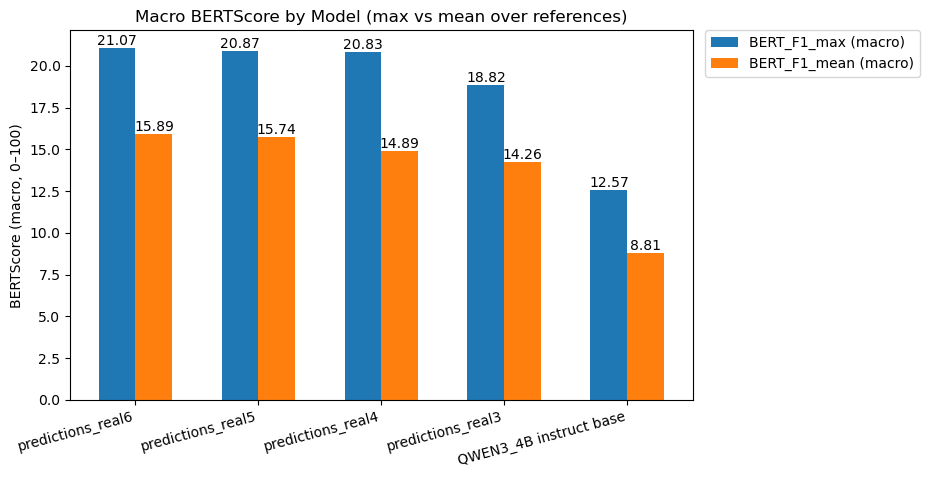

In [44]:
plt.figure(figsize=(9.5, 4.8))
plt.bar(x - w/2, y_max,  width=w, label="BERT_F1_max (macro)")
plt.bar(x + w/2, y_mean, width=w, label="BERT_F1_mean (macro)")

plt.xticks(x, models, rotation=15, ha="right")
plt.ylabel("BERTScore (macro, 0–100)")
plt.title("Macro BERTScore by Model (max vs mean over references)")

# Move legend outside on the right
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)

# Give room for the external legend
plt.gcf().subplots_adjust(right=0.78)

# Annotate bars
for xi, v in zip(x - w/2, y_max):
    plt.text(xi, v, f"{v:.2f}", ha="center", va="bottom")
for xi, v in zip(x + w/2, y_mean):
    plt.text(xi, v, f"{v:.2f}", ha="center", va="bottom")

plt.show()

In [45]:
pd.set_option("display.max_colwidth", 200)

def _trunc(s: str, L: int) -> str:
    return (s[:L] + "…") if isinstance(s, str) and len(s) > L else s

def show_per_row(model: str | None = None,
                 set_id: str | None = None,
                 head_n: int | None = None) -> pd.DataFrame:
    """
    Display per-row metrics with optional filtering.
      - model: e.g., "predictions_real6"
      - set_id: e.g., "predictions_real6.xlsx::set3"
      - head_n: show only the first N rows after sorting
    """
    cols = ["model","set_id","prompt_id","run",
            "BERT_F1_max","BERT_F1_mean",
            "output","references","prompt_text"]
    df = metrics_by_run[cols].copy()

    if model is not None:
        df = df[df["model"] == model]
    if set_id is not None:
        df = df[df["set_id"] == set_id]

    # Sort for readability
    df = df.sort_values(["model","set_id","prompt_id","run"], kind="stable")

    # Truncate long text fields for display
    df["output"] = df["output"].map(lambda s: _trunc(s, 160))
    df["prompt_text"] = df["prompt_text"].map(lambda s: _trunc(s, 120))
    df["references"] = df["references"].map(
        lambda rs: [ _trunc(r, 100) for r in rs ] if isinstance(rs, list) else rs
    )

    if head_n:
        df = df.head(head_n)

    display(df.round({"BERT_F1_max": 3, "BERT_F1_mean": 3}))
    return df

# Show all rows (may be long). Example filtered calls:
# _ = show_per_row(model="predictions_real6")
# _ = show_per_row(set_id="predictions_real6.xlsx::set5")
_ = show_per_row()

,model,set_id,prompt_id,run,BERT_F1_max,BERT_F1_mean,output,references,prompt_text
0,predictions_real1,predictions_real1.xlsx::set1,0,1,10.089000,9.518,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东站·大剧院** \n 位于成都市锦江区，是大型演出和演唱会的常用场地，常有女团或音乐类演出。\n\n2. **成都体育中心·体育馆** \n 举办过多次大型偶像团体演唱会，场地容量大，设施完善。\n\n3. **成都IFS（国际金融…,"[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可能变动；请以主办方及场馆官网公告为准。, 本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准, 建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不被遮挡的看台区]",成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
1,predictions_real1,predictions_real1.xlsx::set1,0,2,10.089000,9.518,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东站·大剧院** \n 位于成都市锦江区，是大型演出和演唱会的常用场地，常有女团或音乐类演出。\n\n2. **成都体育中心·体育馆** \n 举办过多次大型偶像团体演唱会，场地容量大，设施完善。\n\n3. **成都IFS（国际金融…,"[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可能变动；请以主办方及场馆官网公告为准。, 本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准, 建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不被遮挡的看台区]",成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
2,predictions_real1,predictions_real1.xlsx::set1,0,3,10.089000,9.518,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东站·大剧院** \n 位于成都市锦江区，是大型演出和演唱会的常用场地，常有女团或音乐类演出。\n\n2. **成都体育中心·体育馆** \n 举办过多次大型偶像团体演唱会，场地容量大，设施完善。\n\n3. **成都IFS（国际金融…,"[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可能变动；请以主办方及场馆官网公告为准。, 本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准, 建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不被遮挡的看台区]",成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
3,predictions_real1,predictions_real1.xlsx::set2,1,1,8.089000,4.986,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信息基于官方公开资料：\n\n1. **成都科技馆（成都市科学技术馆）** \n - 地址：成都市武侯区人民南路三段18号 \n - 特色：设有“青少年科学乐园”“人工智能体验区”“物理与生命科学互动展区”等，内容贴近中学生认…,"[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动模拟器。可以选择在这里解机体与发动机，部分展项可模拟体验。, 成都自然博物馆：生命科学与地球科学主题较完整，适合科普入门。\n• 参观顺序：先预约→看场馆导览图→优先核心展区→合理控时与补给。\n\n> 信息可能变动；请以各场馆官方预约与开放公告为准。, 可以前往四川科技馆。• 预约：提前在官方渠道...",成都有哪些适合中学生的科技类场馆？
4,predictions_real1,predictions_real1.xlsx::set2,1,2,8.089000,4.986,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信息基于官方公开资料：\n\n1. **成都科技馆（成都市科学技术馆）** \n - 地址：成都市武侯区人民南路三段18号 \n - 特色：设有“青少年科学乐园”“人工智能体验区”“物理与生命科学互动展区”等，内容贴近中学生认…,"[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动模拟器。可以选择在这里解机体与发动机，部分展项可模拟体验。, 成都自然博物馆：生命科学与地球科学主题较完整，适合科普入门。\n• 参观顺序：先预约→看场馆导览图→优先核心展区→合理控时与补给。\n\n> 信息可能变动；请以各场馆官方预约与开放公告为准。, 可以前往四川科技馆。• 预约：提前在官方渠道...",成都有哪些适合中学生的科技类场馆？
...,...,...,...,...,...,...,...,...,...
70,predictions_real6,predictions_real6.xlsx::set4,3,2,25.143000,15.066,成都地道小吃众多，除火锅外，有钟水饺、龙抄手、夫妻肺片等经典川味小吃。地道品尝建议：选择老字号或特色小吃店，参考评分与口碑；注意辣度，可向店家咨询或索要不辣菜品。,"[面点类：担担面、燃面、龙抄手、钟水饺。\n• 小吃类：钵钵鸡、串串、肥肠粉、凉粉、双流兔头（重口味）。\n• 体验区：奎星楼街/太古里周边/望平街等餐饮聚集区选择多。\n• 建议：量小多样更合适；注意辣度与…, 成都的小吃比如甜水面，凉粉，小笼包都好吃。大众点评网上都有详细地址，百度导航都能找到。信息可能变动；请以商家官方与现场告示为准。, 可以考虑体验肝腰合炒，番茄圆子汤，糖醋脆皮鱼等...",除了火锅，成都还有哪些地道小吃值得尝？
71,predictions_real6,predictions_real6.xlsx::set4,3,3,16.962000,5.392,成都地道美食众多，除火锅外，还有：龙抄手（皮薄馅大，抄卤入味）；钟水饺（形似水饺，肉馅鲜美，皮薄）；担担面（面细卤香，咸鲜微辣）。,"[面点类：担担面、燃面、龙抄手、钟水饺。\n• 小吃类：钵钵鸡、串串、肥肠粉、凉粉、双流兔头（重口味）。\n• 体验区：奎星楼街/太古里周边/望平街等餐饮聚集区选择多。\n• 建议：量小多样更合适；注意辣度与…, 成都的小吃比如甜水面，凉粉，小笼包都好吃。大众点评网上都有详细地址，百度导航都能找到。信息可能变动；请以商家官方与现场告示为准。, 可以考虑体验肝腰合炒，番茄圆子汤，糖醋脆皮鱼等...",除了火锅，成都还有哪些地道小吃值得尝？
72,predictions_real6,predictions_real6.xlsx::set5,4,1,23.958000,18.379,成都的公共交通系统非常发达，是西部交通枢纽，游客出行十分便利。\n主要方式：\n地铁：覆盖市区及周边，如3号线、4号线、5号线，可直达武侯祠、锦里、宽窄巷子等。\n公交车：线路众多，可直达景点，如58路到武侯祠，47路到锦里。\n出租车/网约车：方便快捷，但需警惕机场高速费。\n注意事项：\n高峰时段可能拥堵。\n避开早晚高峰，周末…,"[作为中国西部的交通枢纽，成都的交通非常方便。有四通八达的地铁、公交车、出租车和网约车。, 成都的交通非常方便，对于游客来说，最佳出行组合是地铁 + 共享单车/步行，远距离或夜间可以选择网约车和出租车, 在成都市内，可以选择用高德地图或百度地图来导航和查询公交地铁路线， 可以用本地的天府通APP（公交地铁一码通）、支付宝/微信来支付。]",成都的公共交通系统怎么样
73,predictions_real6,predictions_real6.xlsx::set5,4,2,35.009998,29.166,成都市内的公共交通非常便捷，主要由地铁、公交车和出租车/网约车组成。建议您优先选择地铁和公交车，它们更为经济和可靠。具体而言，您可以乘坐地铁和公交车，也可以选择出租车或网约车。,"[作为中国西部的交通枢纽，成都的交通非常方便。有四通八达的地铁、公交车、出租车和网约车。, 成都的交通非常方便，对于游客来说，最佳出行组合是地铁 + 共享单车/步行，远距离或夜间可以选择网约车和出租车, 在成都市内，可以选择用高德地图或百度地图来导航和查询公交地铁路线， 可以用本地的天府通APP（公交地铁一码通）、支付宝/微信来支付。]",成都的公共交通系统怎么样


BLEU

In [49]:
cols_to_keep = [
    "set_id", "prompt_id", "model",
    "BERT_F1_mean_meanOverRuns",  # primary selector
    "BERT_F1_max_meanOverRuns"    # optional, helpful context
]
ap = agg_prompt[cols_to_keep].copy()

# Find the index of the best prompt per (model, set_id)
idx = ap.groupby(["model", "set_id"])["BERT_F1_mean_meanOverRuns"].idxmax()
best = ap.loc[idx].reset_index(drop=True)

# Add prompt text (first occurrence per (set_id, prompt_id))
prompt_meta = (tidy.groupby(["set_id", "prompt_id"], as_index=False)
                   .agg(prompt_text=("prompt_text", "first")))

best = best.merge(prompt_meta, on=["set_id", "prompt_id"], how="left")

# Sort for presentation
best = best.sort_values(["model", "set_id"]).reset_index(drop=True)
best

,set_id,prompt_id,model,BERT_F1_mean_meanOverRuns,BERT_F1_max_meanOverRuns,prompt_text
0,predictions_real1.xlsx::set1,0,QWEN3_4B instruct base,9.517911,10.088530,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
1,predictions_real1.xlsx::set2,1,QWEN3_4B instruct base,4.986031,8.089128,成都有哪些适合中学生的科技类场馆？
2,predictions_real1.xlsx::set3,2,QWEN3_4B instruct base,16.099464,23.697275,第一次去成都大熊猫繁育研究基地，有哪些实用建议？
3,predictions_real1.xlsx::set4,3,QWEN3_4B instruct base,1.118879,7.952025,除了火锅，成都还有哪些地道小吃值得尝？
4,predictions_real1.xlsx::set5,4,QWEN3_4B instruct base,12.314568,13.005604,成都的公共交通系统怎么样
5,predictions_real3.xlsx::set1,0,predictions_real3,21.518158,27.434423,成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？
6,predictions_real3.xlsx::set2,1,predictions_real3,12.014023,12.879886,成都有哪些适合中学生的科技类场馆？
7,predictions_real3.xlsx::set3,2,predictions_real3,12.809445,18.845366,第一次去成都大熊猫繁育研究基地，有哪些实用建议？
8,predictions_real3.xlsx::set4,3,predictions_real3,13.694999,21.613396,除了火锅，成都还有哪些地道小吃值得尝？
9,predictions_real3.xlsx::set5,4,predictions_real3,11.253875,13.350736,成都的公共交通系统怎么样


BLEU

In [53]:

def _norm_text(x):
    # cast to string for NaNs/None
    if x is None:
        return ""
    if isinstance(x, float) and np.isnan(x):
        return ""
    return str(x)

def _bleu_single(hyp: str, ref: str) -> float: # Sentence BLEU via sacrebleu.sentence_bleu tokenize='zh' 0..100 scale.
    hyp = _norm_text(hyp)
    ref = _norm_text(ref)
    res = sacrebleu.sentence_bleu(
        hyp, [ref],
        tokenize="zh", # chinese
        smooth_method="exp",
        smooth_value=0.0,
        use_effective_order=True,  
    )
    return float(res.score)

def _bleu_stats_for_row(hyp: str, refs: list[str]) -> dict:
    if not refs:
        return {"BLEU_mean": 0.0, "BLEU_max": 0.0}
    per_ref = [_bleu_single(hyp, r) for r in refs]
    return {"BLEU_mean": float(np.mean(per_ref)),
            "BLEU_max":  float(np.max(per_ref))}

def compute_bleu_per_row(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, r in df.iterrows():
        stats = _bleu_stats_for_row(r["output"], r["references"])
        rows.append(stats)
    out = pd.DataFrame(rows, index=df.index)
    return df.join(out)

In [54]:
# Recompute and preview
metrics_bleu_by_run = compute_bleu_per_row(tidy.copy())
display(metrics_bleu_by_run.head(6))

,set_id,prompt_id,model,run,output,references,prompt_text,BLEU_mean,BLEU_max
0,predictions_real1.xlsx::set1,0,QWEN3_4B instruct base,1,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东站·大剧院** \n 位于成都市锦江区，是大型演出和演唱会的常用场地，常有女团或音乐类演出。\n\n2. **成都体育中心·体育馆** \n 举办过多次大型偶像团体演唱会，场地容量大，设施完善。\n\n3. **成都IFS（国际金融中心）** \n 位于市中心，拥有专业演艺厅，适合...,"[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可能变动；请以主办方及场馆官网公告为准。, 本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准, 建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不被遮挡的看台区]",成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,2.285936,3.900322
1,predictions_real1.xlsx::set1,0,QWEN3_4B instruct base,2,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东站·大剧院** \n 位于成都市锦江区，是大型演出和演唱会的常用场地，常有女团或音乐类演出。\n\n2. **成都体育中心·体育馆** \n 举办过多次大型偶像团体演唱会，场地容量大，设施完善。\n\n3. **成都IFS（国际金融中心）** \n 位于市中心，拥有专业演艺厅，适合...,"[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可能变动；请以主办方及场馆官网公告为准。, 本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准, 建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不被遮挡的看台区]",成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,2.285936,3.900322
2,predictions_real1.xlsx::set1,0,QWEN3_4B instruct base,3,成都适合观看女团演出的场地主要包括以下几类，具体以官方活动公告为准：\n\n1. **成都东站·大剧院** \n 位于成都市锦江区，是大型演出和演唱会的常用场地，常有女团或音乐类演出。\n\n2. **成都体育中心·体育馆** \n 举办过多次大型偶像团体演唱会，场地容量大，设施完善。\n\n3. **成都IFS（国际金融中心）** \n 位于市中心，拥有专业演艺厅，适合...,"[可以前往成都东郊印象观看本地的CGT48女团演出，购票渠道可以选择官方的微信小程序。 信息可能变动；请以主办方及场馆官网公告为准。, 本地的CGT48女团非常出名，建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准, 建议关注“CGT48”剧场/专场与小舞台活动，票务以官方小程序/票务平台为准，优先选择视线不被遮挡的看台区]",成都有哪些比较适合观看女团演出的场地？购票有什么注意事项？,2.285936,3.900322
3,predictions_real1.xlsx::set2,1,QWEN3_4B instruct base,1,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信息基于官方公开资料：\n\n1. **成都科技馆（成都市科学技术馆）** \n - 地址：成都市武侯区人民南路三段18号 \n - 特色：设有“青少年科学乐园”“人工智能体验区”“物理与生命科学互动展区”等，内容贴近中学生认知水平，适合开展科技主题研学。 \n - 说明：馆内有大量...,"[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动模拟器。可以选择在这里解机体与发动机，部分展项可模拟体验。, 成都自然博物馆：生命科学与地球科学主题较完整，适合科普入门。\n• 参观顺序：先预约→看场馆导览图→优先核心展区→合理控时与补给。\n\n> 信息可能变动；请以各场馆官方预约与开放公告为准。, 可以前往四川科技馆。• 预约：提前在官方渠道...",成都有哪些适合中学生的科技类场馆？,1.648313,2.003940
4,predictions_real1.xlsx::set2,1,QWEN3_4B instruct base,2,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信息基于官方公开资料：\n\n1. **成都科技馆（成都市科学技术馆）** \n - 地址：成都市武侯区人民南路三段18号 \n - 特色：设有“青少年科学乐园”“人工智能体验区”“物理与生命科学互动展区”等，内容贴近中学生认知水平，适合开展科技主题研学。 \n - 说明：馆内有大量...,"[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动模拟器。可以选择在这里解机体与发动机，部分展项可模拟体验。, 成都自然博物馆：生命科学与地球科学主题较完整，适合科普入门。\n• 参观顺序：先预约→看场馆导览图→优先核心展区→合理控时与补给。\n\n> 信息可能变动；请以各场馆官方预约与开放公告为准。, 可以前往四川科技馆。• 预约：提前在官方渠道...",成都有哪些适合中学生的科技类场馆？,1.648313,2.003940
5,predictions_real1.xlsx::set2,1,QWEN3_4B instruct base,3,成都市有多个适合中学生的科技类场馆，以下是一些推荐的、以互动性、科普性和趣味性著称的场馆，信息基于官方公开资料：\n\n1. **成都科技馆（成都市科学技术馆）** \n - 地址：成都市武侯区人民南路三段18号 \n - 特色：设有“青少年科学乐园”“人工智能体验区”“物理与生命科学互动展区”等，内容贴近中学生认知水平，适合开展科技主题研学。 \n - 说明：馆内有大量...,"[成都的立巢航空博物馆是国内领先的民营航空博物馆。拥有大量真实飞机、发动机展品以及丰富的互动模拟器。可以选择在这里解机体与发动机，部分展项可模拟体验。, 成都自然博物馆：生命科学与地球科学主题较完整，适合科普入门。\n• 参观顺序：先预约→看场馆导览图→优先核心展区→合理控时与补给。\n\n> 信息可能变动；请以各场馆官方预约与开放公告为准。, 可以前往四川科技馆。• 预约：提前在官方渠道...",成都有哪些适合中学生的科技类场馆？,1.648313,2.003940


Mean:

Run level

In [55]:
agg_prompt_bleu = (metrics_bleu_by_run
                   .groupby(["set_id","prompt_id","model"], as_index=False)
                   .agg(BLEU_mean_meanOverRuns=("BLEU_mean","mean"),
                        BLEU_max_meanOverRuns=("BLEU_max","mean")))

set level

In [56]:
within_set_bleu = (agg_prompt_bleu
                   .groupby(["set_id","model"], as_index=False)
                   .agg(BLEU_mean_setMean=("BLEU_mean_meanOverRuns","mean"),
                        BLEU_max_setMean=("BLEU_max_meanOverRuns","mean")))

Macro 

In [57]:
macro_bleu = (within_set_bleu
              .groupby("model", as_index=False)
              .agg(BLEU_mean_macro=("BLEU_mean_setMean","mean"),
                   BLEU_max_macro=("BLEU_max_setMean","mean")))

In [58]:
prompts_per_set = (agg_prompt_bleu.groupby(["set_id","model"])["prompt_id"]
                   .count().reset_index(name="n_prompts"))
within_set_w = within_set_bleu.merge(prompts_per_set, on=["set_id","model"], how="left")
micro_bleu = (within_set_w.groupby("model", as_index=False)
              .apply(lambda g: pd.Series({
                  "BLEU_mean_micro": float(np.average(g["BLEU_mean_setMean"], weights=g["n_prompts"])),
                  "BLEU_max_micro":  float(np.average(g["BLEU_max_setMean"],  weights=g["n_prompts"])),
                  "n_prompts_total": int(g["n_prompts"].sum())
              }))).reset_index(drop=True)

C:\Users\xjie\AppData\Local\Temp\ipykernel_38408\1382635136.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [59]:
leaderboard_bleu = (macro_bleu.merge(micro_bleu, on="model", how="left")
                    .sort_values("BLEU_max_macro", ascending=False)
                    .reset_index(drop=True))

In [60]:
models = leaderboard_bleu["model"].tolist()
y_max  = leaderboard_bleu["BLEU_max_macro"].to_numpy()
y_mean = leaderboard_bleu["BLEU_mean_macro"].to_numpy()

In [61]:
x = np.arange(len(models))
w = 0.38

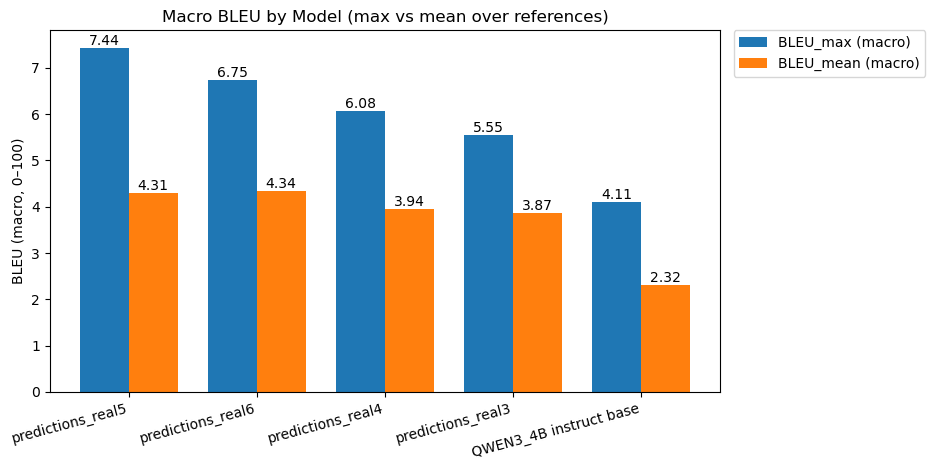

In [63]:
plt.figure(figsize=(9.5, 4.8))
plt.bar(x - w/2, y_max,  width=w, label="BLEU_max (macro)")
plt.bar(x + w/2, y_mean, width=w, label="BLEU_mean (macro)")

plt.xticks(x, models, rotation=15, ha="right")
plt.ylabel("BLEU (macro, 0–100)")
plt.title("Macro BLEU by Model (max vs mean over references)")

# Legend outside on the right
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.)
plt.gcf().subplots_adjust(right=0.78)

# Annotate bars
for xi, v in zip(x - w/2, y_max):
    plt.text(xi, v, f"{v:.2f}", ha="center", va="bottom")
for xi, v in zip(x + w/2, y_mean):
    plt.text(xi, v, f"{v:.2f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()